<a href="https://colab.research.google.com/github/junedkhan9310/card-symbol-recognition-opencv/blob/main/card_symbol_recognition_opencv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

the image is like cpatcha image has 2 cards like 5 of spades or two of diamonds and options have 6 cards where two of them is that and i wanna indsnity them

#This is old logic that i;ve implemented but not working because of enhanced img

In [ ]:
import cv2
import numpy as np

def compare_captcha_images():

    try:
        captcha_path = "/content/captcha_question.png"
        captcha_image = cv2.imread(captcha_path, cv2.IMREAD_COLOR)

        if captcha_image is None:
            print("Failed to load captcha question image")
            return

        threshold = 0.8
        best_score = 0
        best_index = None

        for i in range(1, 7):

            template_path = f"/content/captcha_opt_{i}.png"
            template = cv2.imread(template_path, cv2.IMREAD_COLOR)

            if template is None:
                print(f"Failed to load option {i}")
                continue

            result = cv2.matchTemplate(captcha_image, template, cv2.TM_CCOEFF_NORMED)
            min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

            print(f"Option {i} similarity score: {max_val}")

            if max_val > best_score:
                best_score = max_val
                best_index = i

        print("\nBest Match Option:", best_index)
        print("Best Similarity Score:", best_score)

        if best_score >= threshold:
            print("Captcha match detected ✅")
        else:
            print("No strong match found ❌")

    except Exception as e:
        print("Error:", e)


compare_captcha_images()

Option 1 similarity score: 0.335843563079834
Option 2 similarity score: 0.19344960153102875
Option 3 similarity score: 0.33302897214889526
Option 4 similarity score: 0.24291996657848358
Option 5 similarity score: 0.3740111291408539
Option 6 similarity score: 0.39704540371894836

Best Match Option: 6
Best Similarity Score: 0.39704540371894836
No strong match found ❌


#Now let's start with new refactored and improved version

In [ ]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim


def preprocess(img):
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Remove noise
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Edge detection
    edges = cv2.Canny(blur, 50, 150)

    return edges


def compare_images(img1, img2):

    # Resize template to captcha size
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Calculate SSIM score
    score, _ = ssim(img1, img2, full=True)

    return score


def compare_captcha_images():

    try:

        captcha_path = "/content/captcha_question.png"
        captcha_image = cv2.imread(captcha_path)

        if captcha_image is None:
            print("Failed to load captcha question image")
            return

        captcha_image = preprocess(captcha_image)

        best_score = -1
        best_index = None

        for i in range(1, 7):

            template_path = f"/content/captcha_opt_{i}.png"
            template = cv2.imread(template_path)

            if template is None:
                print(f"Failed to load option {i}")
                continue

            template = preprocess(template)

            score = compare_images(captcha_image, template)

            print(f"Option {i} similarity score: {score:.4f}")

            if score > best_score:
                best_score = score
                best_index = i

        print("\nBest Match Option:", best_index)
        print("Best Similarity Score:", best_score)

        if best_score > 0.5:
            print("Captcha match detected ✅")
        else:
            print("Low confidence match ❌")

    except Exception as e:
        print("Error:", e)


compare_captcha_images()

Option 1 similarity score: 0.7159
Option 2 similarity score: 0.7249
Option 3 similarity score: 0.7869
Option 4 similarity score: 0.6661
Option 5 similarity score: 0.6765
Option 6 similarity score: 0.6638

Best Match Option: 3
Best Similarity Score: 0.7868905991310765
Captcha match detected ✅


In [ ]:
import cv2
import numpy as np

def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    return blur


def compare_orb(img1, img2):

    orb = cv2.ORB_create(nfeatures=2000)

    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    return len(matches)


def compare_captcha_images():

    captcha_path = "/content/captcha_question.png"
    captcha = cv2.imread(captcha_path)

    if captcha is None:
        print("Captcha image not found")
        return

    captcha = preprocess(captcha)

    best_score = 0
    best_index = None

    for i in range(1,7):

        template_path = f"/content/captcha_opt_{i}.png"
        template = cv2.imread(template_path)

        if template is None:
            print(f"Option {i} not found")
            continue

        template = preprocess(template)

        score = compare_orb(captcha, template)

        print(f"Option {i} match score: {score}")

        if score > best_score:
            best_score = score
            best_index = i

    print("\nBest Match Option:", best_index)
    print("Best Score:", best_score)


compare_captcha_images()

Option 1 match score: 47
Option 2 match score: 75
Option 3 match score: 22
Option 4 match score: 40
Option 5 match score: 20
Option 6 match score: 72

Best Match Option: 2
Best Score: 75


In [ ]:
import cv2
import numpy as np

def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    return gray


def orb_score(img1, img2):

    orb = cv2.ORB_create(2000)

    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    matches = bf.match(des1, des2)

    return len(matches)


def split_cards(img):

    h, w = img.shape[:2]

    # split captcha into left and right cards
    card1 = img[:, :w//2]
    card2 = img[:, w//2:]

    return [card1, card2]


def solve_captcha():

    captcha = cv2.imread("/content/captcha_question.png")

    if captcha is None:
        print("Captcha not found")
        return

    cards = split_cards(captcha)

    cards = [preprocess(c) for c in cards]

    option_images = []

    for i in range(1,7):
        img = cv2.imread(f"/content/captcha_opt_{i}.png")

        if img is None:
            print(f"Option {i} missing")
            continue

        option_images.append((i, preprocess(img)))

    matches = []

    for idx, opt in option_images:

        score1 = orb_score(cards[0], opt)
        score2 = orb_score(cards[1], opt)

        score = max(score1, score2)

        print(f"Option {idx} score: {score}")

        matches.append((score, idx))

    matches.sort(reverse=True)

    print("\nDetected cards:")
    print("Option", matches[0][1])
    print("Option", matches[1][1])


solve_captcha()

Option 1 score: 33
Option 2 score: 61
Option 3 score: 15
Option 4 score: 32
Option 5 score: 18
Option 6 score: 60

Detected cards:
Option 2
Option 6


In [ ]:
import cv2
import numpy as np

def color_score(img1, img2):

    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    hist1 = cv2.calcHist([img1], [0,1,2], None, [8,8,8], [0,256,0,256,0,256])
    hist2 = cv2.calcHist([img2], [0,1,2], None, [8,8,8], [0,256,0,256,0,256])

    cv2.normalize(hist1, hist1)
    cv2.normalize(hist2, hist2)

    return cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)


def orb_score(img1, img2):

    orb = cv2.ORB_create(2000)

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    matches = bf.match(des1, des2)

    return len(matches)


def split_cards(img):

    h, w = img.shape[:2]

    card1 = img[:, :w//2]
    card2 = img[:, w//2:]

    return [card1, card2]


def solve_captcha():

    captcha = cv2.imread("/content/captcha_question.png")

    cards = split_cards(captcha)

    options = []

    for i in range(1,7):
        img = cv2.imread(f"/content/captcha_opt_{i}.png")
        options.append((i, img))

    scores = []

    for idx, opt in options:

        score_total = 0

        for card in cards:

            orb = orb_score(card, opt)
            color = color_score(card, opt)

            score = (0.6 * orb) + (0.4 * color * 100)

            score_total += score

        print(f"Option {idx} score: {score_total}")

        scores.append((score_total, idx))

    scores.sort(reverse=True)

    print("\nBest Matches:")
    print(scores[0][1])
    print(scores[1][1])


solve_captcha()

Option 1 score: 137.5583695075882
Option 2 score: 166.2856200382593
Option 3 score: 127.3353683816858
Option 4 score: 136.32774732974113
Option 5 score: 111.73431492932596
Option 6 score: 153.00959372131587

Best Matches:
2
6


# Another try

In [ ]:
import cv2
import numpy as np

# Config: percentage of card to crop for rank+suit patch
PATCH_RATIO = 0.25  # top-left 25% of width/height

def preprocess(img):
    # Smooth slightly to reduce noise, keep color
    return cv2.GaussianBlur(img, (3,3), 0)

def extract_cards(captcha_img):
    gray = cv2.cvtColor(captcha_img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(blur, 120, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Sort contours by area (largest two assumed to be cards)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]

    cards = []
    for cnt in contours:
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02*peri, True)
        if len(approx) == 4:
            pts = approx.reshape(4,2)
            # Order points: tl, tr, br, bl
            rect = order_points(pts)
            warped = warp_card(captcha_img, rect)
            cards.append(warped)
    return cards

def order_points(pts):
    # Order points: top-left, top-right, bottom-right, bottom-left
    rect = np.zeros((4,2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def warp_card(img, rect, width=200, height=300):
    dst = np.array([[0,0],[width-1,0],[width-1,height-1],[0,height-1]], dtype="float32")
    M = cv2.getPerspectiveTransform(rect, dst)
    warp = cv2.warpPerspective(img, M, (width, height))
    return warp

def extract_patch(card):
    h, w = card.shape[:2]
    patch = card[0:int(h*PATCH_RATIO), 0:int(w*PATCH_RATIO)]
    return patch

def orb_score(img1, img2):
    orb = cv2.ORB_create(2000)
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)
    if des1 is None or des2 is None:
        return 0
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    return len(matches)

def color_score(img1, img2):
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
    hist1 = cv2.calcHist([img1], [0,1,2], None, [8,8,8], [0,256,0,256,0,256])
    hist2 = cv2.calcHist([img2], [0,1,2], None, [8,8,8], [0,256,0,256,0,256])
    cv2.normalize(hist1, hist1)
    cv2.normalize(hist2, hist2)
    return cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)

def solve_captcha():
    captcha = cv2.imread("/content/captcha_question.png")
    cards = extract_cards(captcha)
    if len(cards) < 2:
        print("Could not detect 2 cards")
        return

    card_patches = [extract_patch(c) for c in cards]

    # Load options
    options = []
    for i in range(1,7):
        img = cv2.imread(f"/content/captcha_opt_{i}.png")
        if img is None:
            continue
        options.append((i, img))

    scores = []

    for idx, opt in options:
        patch_opt = extract_patch(opt)
        total_score = 0
        for patch_card in card_patches:
            orb = orb_score(patch_card, patch_opt)
            color = color_score(patch_card, patch_opt)
            score = 0.6*orb + 0.4*color*100  # weighted
            total_score += score
        scores.append((total_score, idx))
        print(f"Option {idx} score: {total_score}")

    # Pick top 2 matches
    scores.sort(reverse=True)
    print("\nDetected cards (option numbers):")
    print(scores[0][1], scores[1][1])

solve_captcha()

Could not detect 2 cards


In [ ]:
!pip install opencv-python matplotlib

import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

#Card comparing

Image shape: (192, 324)
Loaded template: captcha_opt_1.png
Loaded template: captcha_opt_2.png
Loaded template: captcha_opt_3.png
Loaded template: captcha_opt_4.png
Loaded template: captcha_opt_5.png
Loaded template: captcha_opt_6.png

Processing Card 0
Comparing with captcha_opt_1 score: 346552


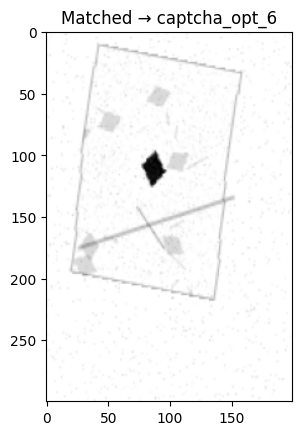

Comparing with captcha_opt_2 score: 1226039


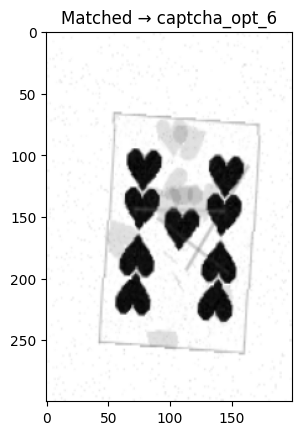

Comparing with captcha_opt_3 score: 524798


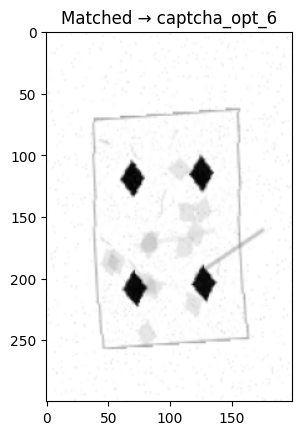

Comparing with captcha_opt_4 score: 824951


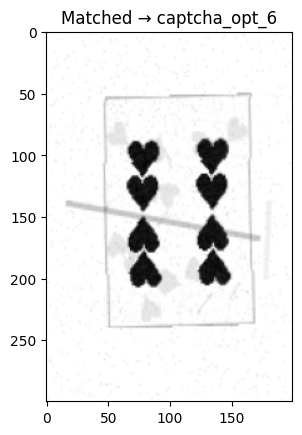

Comparing with captcha_opt_5 score: 367327


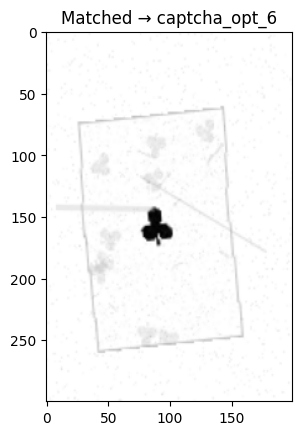

Comparing with captcha_opt_6 score: 597639


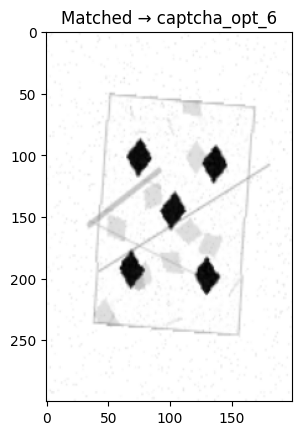

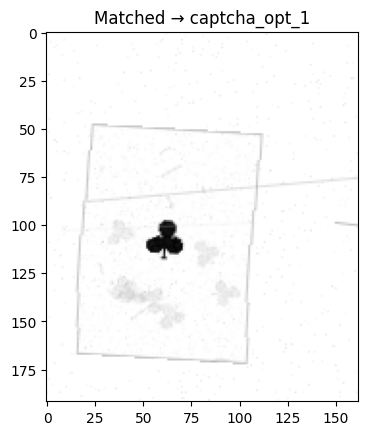


Processing Card 1
Comparing with captcha_opt_1 score: 897493


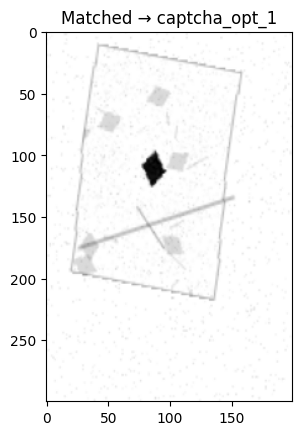

Comparing with captcha_opt_2 score: 1361726


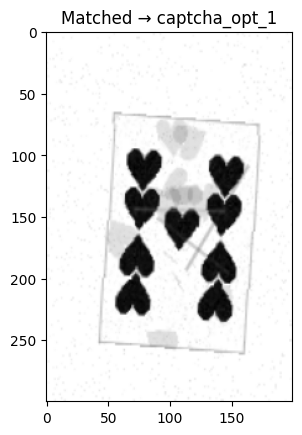

Comparing with captcha_opt_3 score: 883205


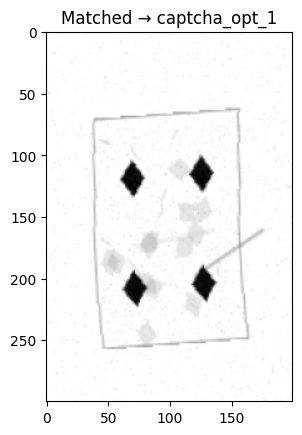

Comparing with captcha_opt_4 score: 909454


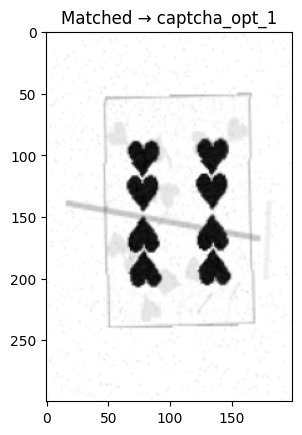

Comparing with captcha_opt_5 score: 935256


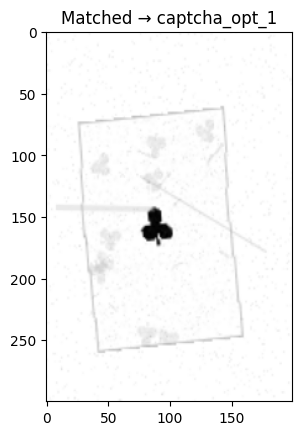

Comparing with captcha_opt_6 score: 848490


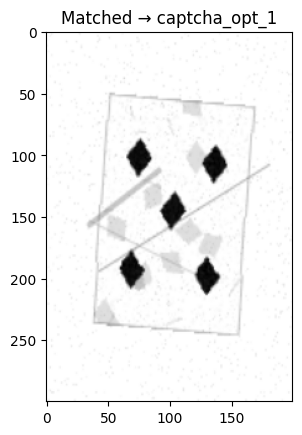

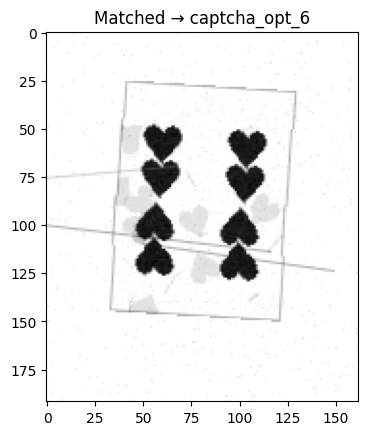


FINAL CAPTCHA ANSWER: ['captcha_opt_1', 'captcha_opt_6']


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# LOAD CAPTCHA
# -----------------------

img = cv2.imread("captcha_question.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Image shape:", gray.shape)

# plt.imshow(gray, cmap="gray")
# plt.title("Original CAPTCHA")
# plt.show()


# -----------------------
# SPLIT IMAGE INTO TWO CARDS
# -----------------------

h, w = gray.shape

left_card = gray[:, :w//2]
right_card = gray[:, w//2:]

cards = [left_card, right_card]


# Debug view
# for i,c in enumerate(cards):

#     plt.imshow(c, cmap="gray")
#     plt.title(f"Card Region {i}")
#     plt.show()


# -----------------------
# LOAD OPTION IMAGES
# -----------------------

templates = {}

for i in range(1,7):

    temp = cv2.imread(f"captcha_opt_{i}.png",0)

    temp = cv2.resize(temp,(200,300))

    templates[f"captcha_opt_{i}"] = temp

    print("Loaded template:",f"captcha_opt_{i}.png")


# -----------------------
# MATCH FUNCTION
# -----------------------

def match_card(card):

    card = cv2.resize(card,(200,300))

    best_score = 999999999
    best_match = None

    for name,temp in templates.items():

        diff = cv2.absdiff(card,temp)

        score = np.sum(diff)

        print("Comparing with",name,"score:",score)
        plt.imshow(temp,cmap="gray")
        plt.title(f"Matched → {match}")
        plt.show()

        if score < best_score:

            best_score = score
            best_match = name

    return best_match


# -----------------------
# IDENTIFY CARDS
# -----------------------

answers = []

for i,card in enumerate(cards):

    print("\nProcessing Card",i)

    match = match_card(card)

    answers.append(match)

    plt.imshow(card,cmap="gray")
    plt.title(f"Matched → {match}")
    plt.show()


print("\nFINAL CAPTCHA ANSWER:",answers)

# Using black part as area and then let's comapre


Processing Card


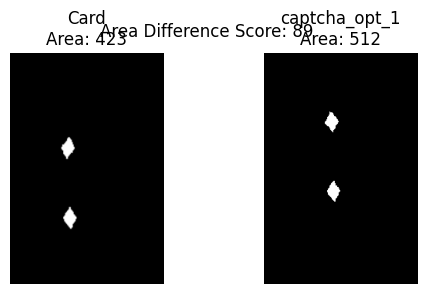

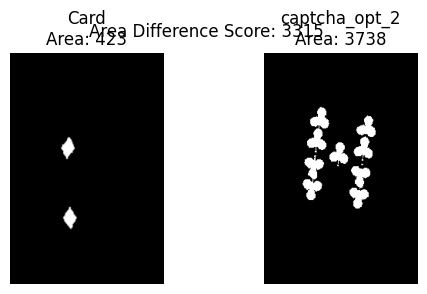

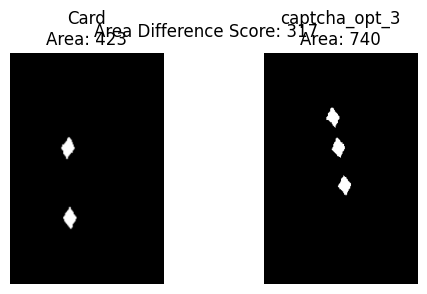

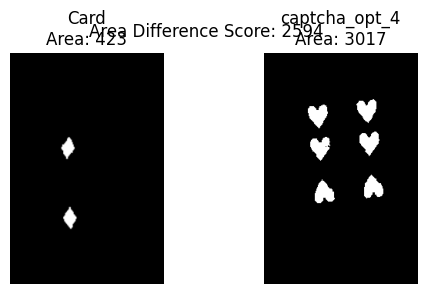

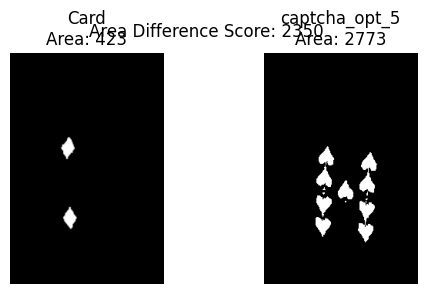

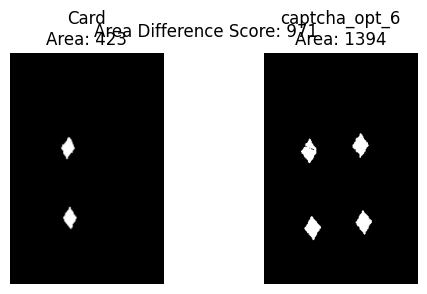


Processing Card


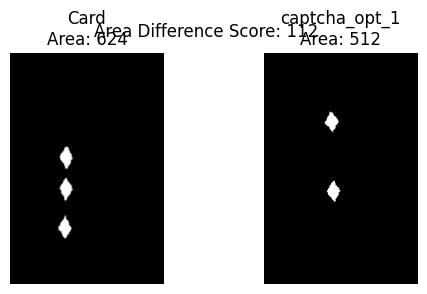

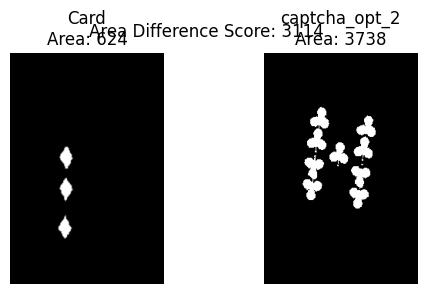

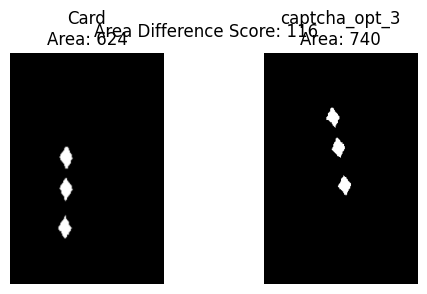

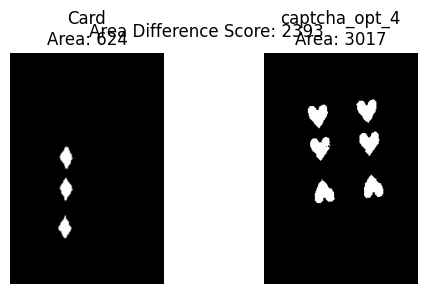

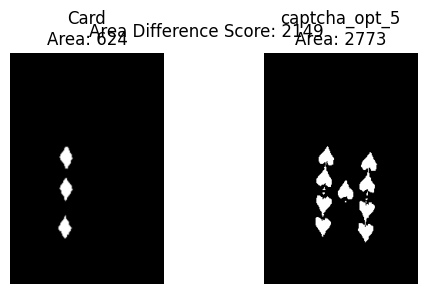

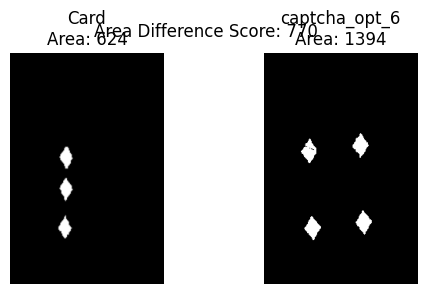

Final Answer: ['captcha_opt_1', 'captcha_opt_1']


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# LOAD CAPTCHA
# -----------------------

img = cv2.imread("captcha_question.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# keep only darkest pixels
_, gray = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY_INV)


# -----------------------
# SPLIT IMAGE INTO TWO CARDS
# -----------------------

h, w = gray.shape

left_card = gray[:, :w//2]
right_card = gray[:, w//2:]

cards = [left_card, right_card]


# -----------------------
# LOAD OPTION IMAGES
# -----------------------

templates = {}

for i in range(1,7):

    temp = cv2.imread(f"captcha_opt_{i}.png",0)
    temp = cv2.resize(temp,(200,300))

    _, temp = cv2.threshold(temp,120,255,cv2.THRESH_BINARY_INV)

    templates[f"captcha_opt_{i}"] = temp


# -----------------------
# MATCH FUNCTION
# -----------------------

def match_card(card):

    card = cv2.resize(card,(200,300))

    card_area = np.sum(card == 255)

    best_score = float("inf")
    best_match = None

    for name,temp in templates.items():

        temp_area = np.sum(temp == 255)

        score = abs(card_area - temp_area)

        # -----------------------
        # DEBUG VISUALIZATION
        # -----------------------

        fig, ax = plt.subplots(1,2,figsize=(6,3))

        ax[0].imshow(card,cmap="gray")
        ax[0].set_title(f"Card\nArea: {card_area}")
        ax[0].axis("off")

        ax[1].imshow(temp,cmap="gray")
        ax[1].set_title(f"{name}\nArea: {temp_area}")
        ax[1].axis("off")

        fig.suptitle(f"Area Difference Score: {score}")

        plt.show()

        if score < best_score:

            best_score = score
            best_match = name

    return best_match

# -----------------------
# IDENTIFY CARDS
# -----------------------

answers = []

for card in cards:
    print("\nProcessing Card")
    match = match_card(card)
    answers.append(match)

print("Final Answer:",answers)

#Area try again but with tweak

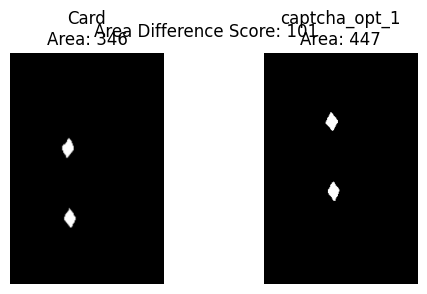

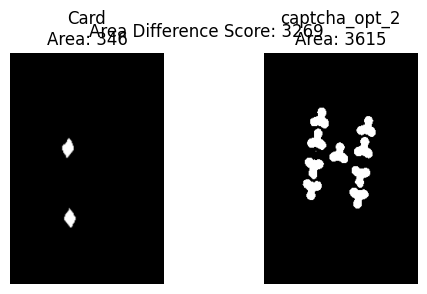

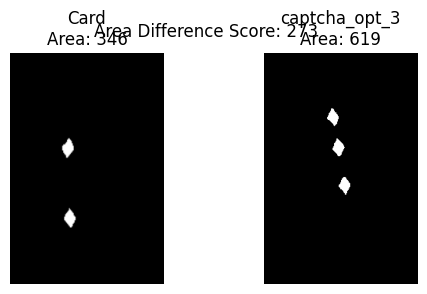

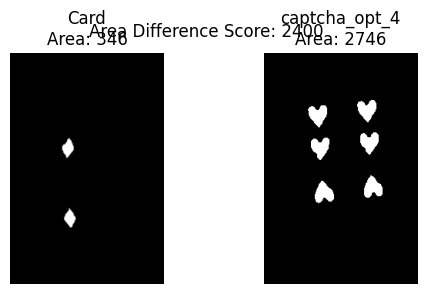

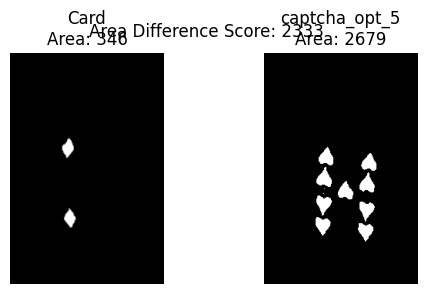

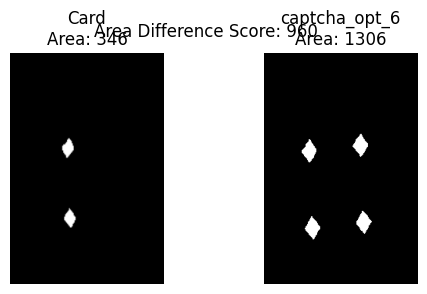

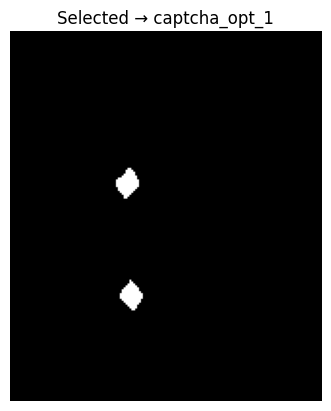

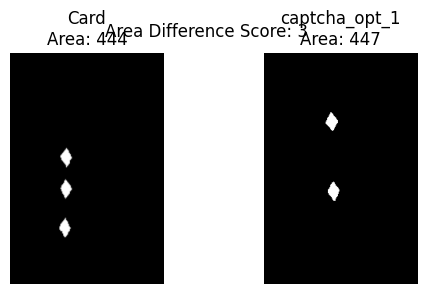

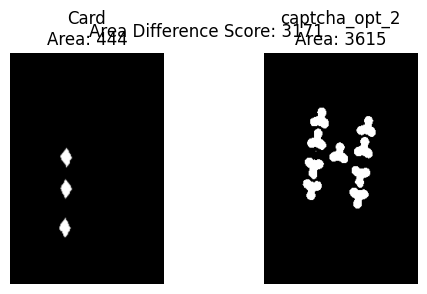

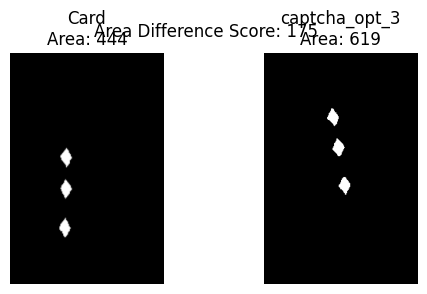

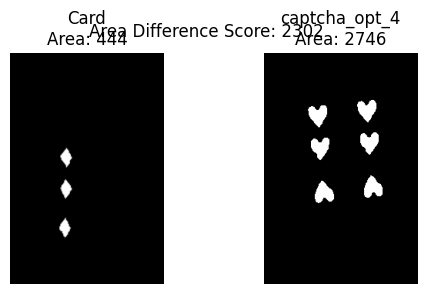

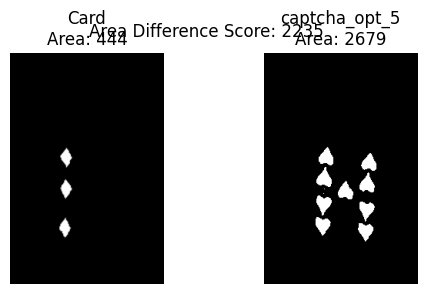

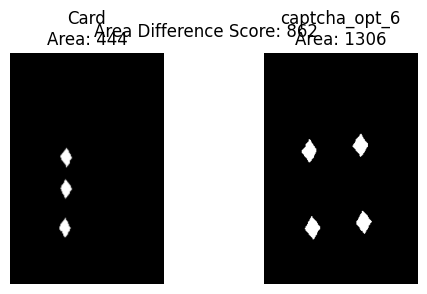

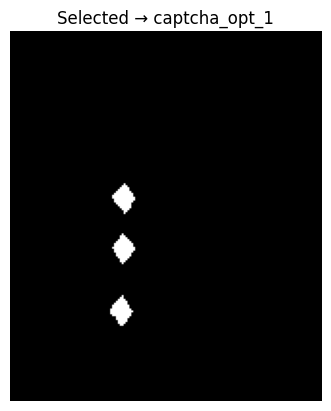

Final Answer: ['captcha_opt_1', 'captcha_opt_1']


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# -----------------------
# LOAD CAPTCHA
# -----------------------

img = cv2.imread("captcha_question.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# reduce captcha speckle noise
gray = cv2.GaussianBlur(gray,(5,5),0)

# keep only darkest pixels (symbols)
_, gray = cv2.threshold(gray,120,255,cv2.THRESH_BINARY_INV)


# -----------------------
# SPLIT IMAGE INTO TWO CARDS
# -----------------------

h, w = gray.shape

left_card = gray[:, :w//2]
right_card = gray[:, w//2:]

cards = [left_card, right_card]


# -----------------------
# LOAD OPTION IMAGES
# -----------------------

templates = {}

for i in range(1,7):

    temp = cv2.imread(f"captcha_opt_{i}.png",0)

    temp = cv2.resize(temp,(200,300))

    # clean template the same way
    temp = cv2.GaussianBlur(temp,(5,5),0)
    _, temp = cv2.threshold(temp,120,255,cv2.THRESH_BINARY_INV)

    templates[f"captcha_opt_{i}"] = temp


# -----------------------
# MATCH FUNCTION (AREA BASED)
# -----------------------

def match_card(card):

    card = cv2.resize(card,(200,300))

    # area of white pixels (symbol area)
    card_area = np.sum(card == 255)

    best_score = float("inf")
    best_match = None

    for name,temp in templates.items():

        temp_area = np.sum(temp == 255)

        score = abs(card_area - temp_area)

        # -----------------------
        # DEBUG VISUALIZATION
        # -----------------------

        fig, ax = plt.subplots(1,2,figsize=(6,3))

        ax[0].imshow(card,cmap="gray")
        ax[0].set_title(f"Card\nArea: {card_area}")
        ax[0].axis("off")

        ax[1].imshow(temp,cmap="gray")
        ax[1].set_title(f"{name}\nArea: {temp_area}")
        ax[1].axis("off")

        fig.suptitle(f"Area Difference Score: {score}")

        plt.show()

        # choose best match
        if score < best_score:
            best_score = score
            best_match = name

    return best_match


# -----------------------
# IDENTIFY CARDS
# -----------------------

answers = []

for i,card in enumerate(cards):

    match = match_card(card)

    answers.append(match)

    plt.imshow(card,cmap="gray")
    plt.title(f"Selected → {match}")
    plt.axis("off")
    plt.show()


print("Final Answer:",answers)

#Simple comparision again but with one by one with both the card not one

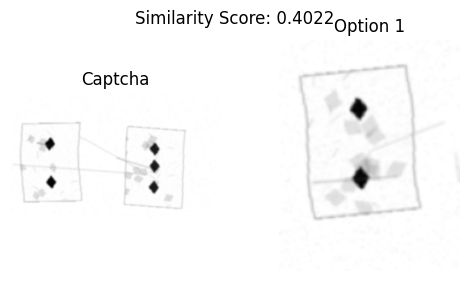

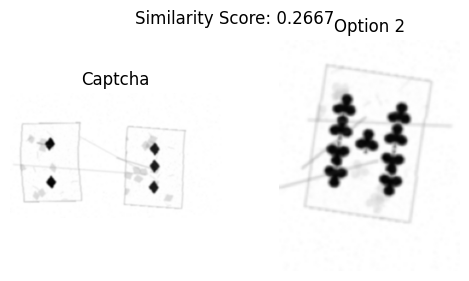

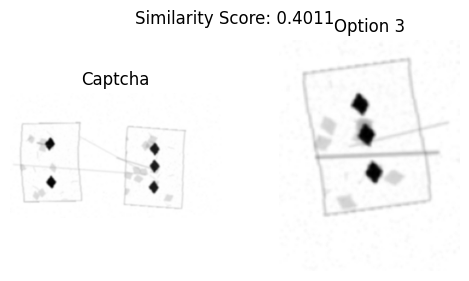

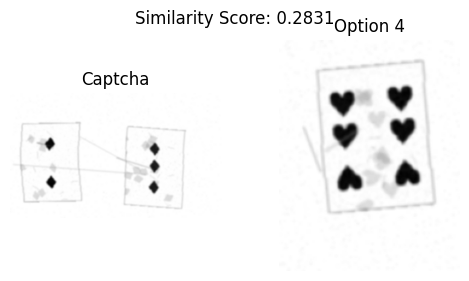

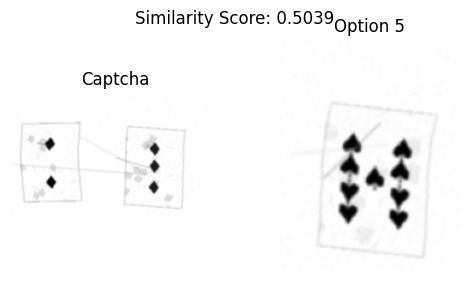

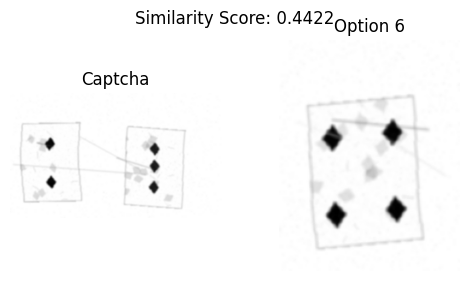


Best Match Option: 5
Best Similarity Score: 0.5039322376251221
No strong match found ❌


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def compare_captcha_images():

    try:

        captcha_path = "captcha_question.png"

        # -----------------------
        # LOAD CAPTCHA
        # -----------------------

        captcha_image = cv2.imread(captcha_path, cv2.IMREAD_GRAYSCALE)

        if captcha_image is None:
            print("Failed to load captcha question image")
            return

        # remove captcha noise
        captcha_image = cv2.GaussianBlur(captcha_image,(5,5),0)


        threshold = 0.8
        best_score = 0
        best_index = None


        # -----------------------
        # LOOP THROUGH OPTIONS
        # -----------------------

        for i in range(1,7):

            template_path = f"captcha_opt_{i}.png"

            template = cv2.imread(template_path, cv2.IMREAD_GRAYSCALE)

            if template is None:
                print(f"Failed to load option {i}")
                continue


            template = cv2.GaussianBlur(template,(5,5),0)


            # -----------------------
            # TEMPLATE MATCH
            # -----------------------

            result = cv2.matchTemplate(
                captcha_image,
                template,
                cv2.TM_CCOEFF_NORMED
            )

            min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)


            # -----------------------
            # DEBUG VISUALIZATION
            # -----------------------

            fig, ax = plt.subplots(1,2,figsize=(6,3))

            ax[0].imshow(captcha_image,cmap="gray")
            ax[0].set_title("Captcha")
            ax[0].axis("off")

            ax[1].imshow(template,cmap="gray")
            ax[1].set_title(f"Option {i}")
            ax[1].axis("off")

            fig.suptitle(f"Similarity Score: {max_val:.4f}")

            plt.show()


            # -----------------------
            # TRACK BEST MATCH
            # -----------------------

            if max_val > best_score:
                best_score = max_val
                best_index = i


        # -----------------------
        # FINAL RESULT
        # -----------------------

        print("\nBest Match Option:", best_index)
        print("Best Similarity Score:", best_score)

        if best_score >= threshold:
            print("Captcha match detected ✅")
        else:
            print("No strong match found ❌")


    except Exception as e:
        print("Error:", e)


compare_captcha_images()

#I've tried with area but it failed because of sizes

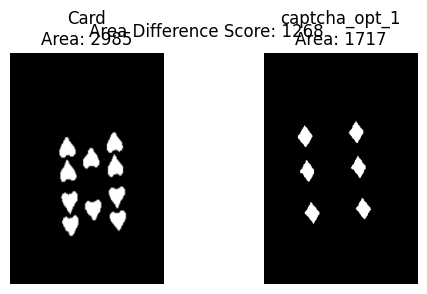

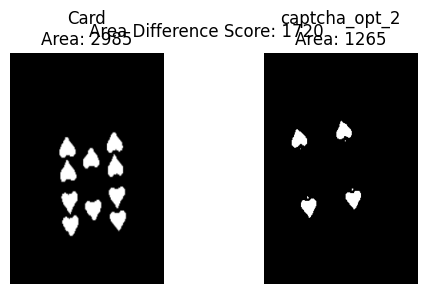

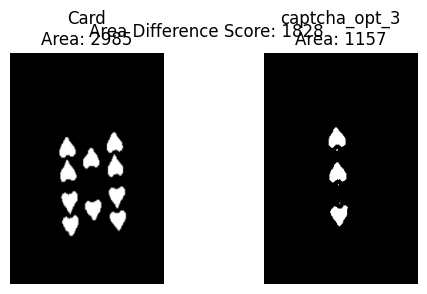

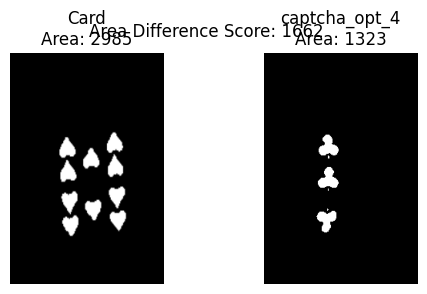

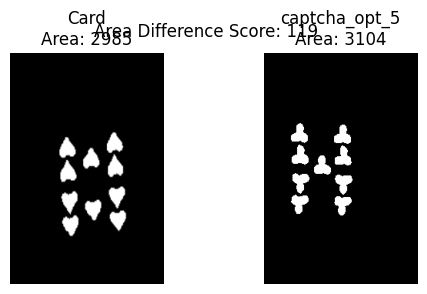

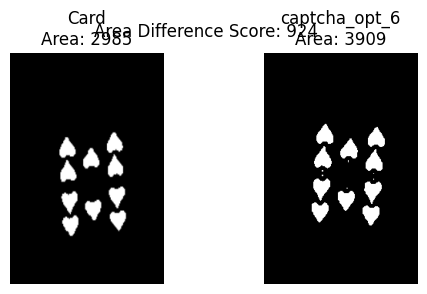

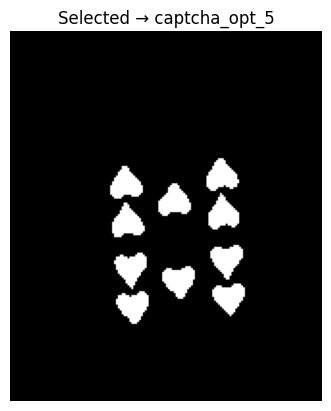

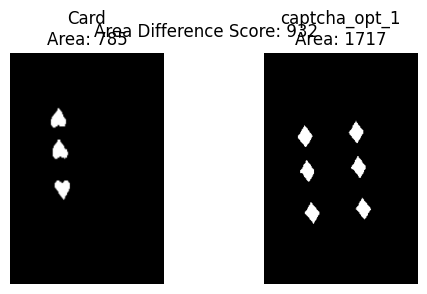

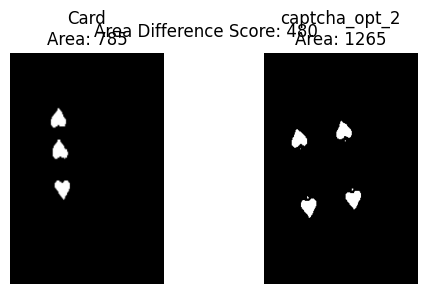

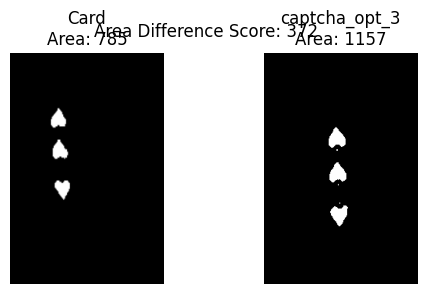

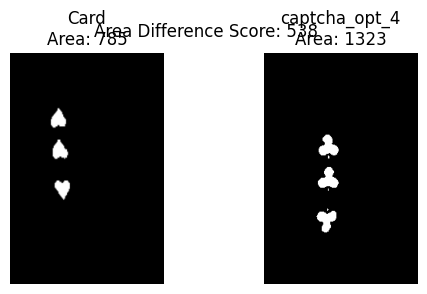

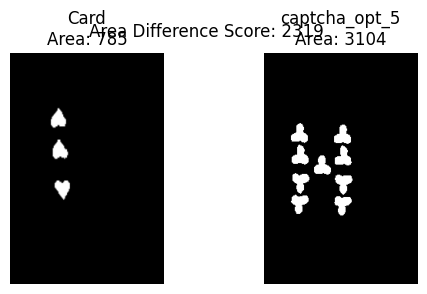

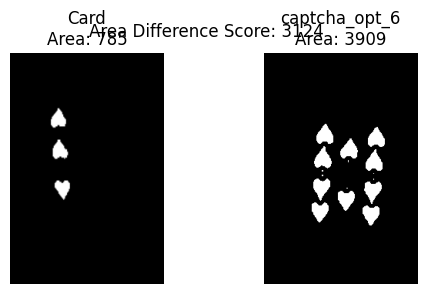

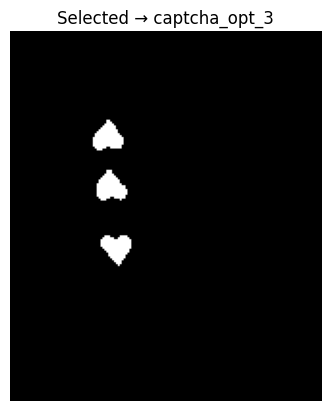

Final Answer: ['captcha_opt_5', 'captcha_opt_3']


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# -----------------------
# LOAD CAPTCHA
# -----------------------

img = cv2.imread("captcha_question.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# reduce captcha speckle noise
gray = cv2.GaussianBlur(gray,(5,5),0)

# keep only darkest pixels (symbols)
_, gray = cv2.threshold(gray,120,255,cv2.THRESH_BINARY_INV)


# -----------------------
# SPLIT IMAGE INTO TWO CARDS
# -----------------------

h, w = gray.shape

left_card = gray[:, :w//2]
right_card = gray[:, w//2:]

cards = [left_card, right_card]


# -----------------------
# LOAD OPTION IMAGES
# -----------------------

templates = {}

for i in range(1,7):

    temp = cv2.imread(f"captcha_opt_{i}.png",0)

    temp = cv2.resize(temp,(200,300))

    # clean template the same way
    temp = cv2.GaussianBlur(temp,(5,5),0)
    _, temp = cv2.threshold(temp,120,255,cv2.THRESH_BINARY_INV)

    templates[f"captcha_opt_{i}"] = temp


# -----------------------
# MATCH FUNCTION (AREA BASED)
# -----------------------

def match_card(card):

    card = cv2.resize(card,(200,300))

    # area of white pixels (symbol area)
    card_area = np.sum(card == 255)

    best_score = float("inf")
    best_match = None

    for name,temp in templates.items():

        temp_area = np.sum(temp == 255)

        score = abs(card_area - temp_area)

        # -----------------------
        # DEBUG VISUALIZATION
        # -----------------------

        fig, ax = plt.subplots(1,2,figsize=(6,3))

        ax[0].imshow(card,cmap="gray")
        ax[0].set_title(f"Card\nArea: {card_area}")
        ax[0].axis("off")

        ax[1].imshow(temp,cmap="gray")
        ax[1].set_title(f"{name}\nArea: {temp_area}")
        ax[1].axis("off")

        fig.suptitle(f"Area Difference Score: {score}")

        plt.show()

        # choose best match
        if score < best_score:
            best_score = score
            best_match = name

    return best_match


# -----------------------
# IDENTIFY CARDS
# -----------------------

answers = []

for i,card in enumerate(cards):

    match = match_card(card)

    answers.append(match)

    plt.imshow(card,cmap="gray")
    plt.title(f"Selected → {match}")
    plt.axis("off")
    plt.show()


print("Final Answer:",answers)

#Final working code that i've implemented

In [ ]:
import cv2
import numpy as np


# -----------------------
# PREPROCESS
# -----------------------

def preprocess(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray,(5,5),0)

    _,th = cv2.threshold(gray,120,255,cv2.THRESH_BINARY_INV)

    return th


# -----------------------
# GET SYMBOL CONTOURS
# -----------------------

def get_symbols(binary):

    contours,_ = cv2.findContours(binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    symbols = []

    for c in contours:

        if cv2.contourArea(c) > 120:
            symbols.append(c)

    return symbols


# -----------------------
# SHAPE FEATURES
# -----------------------

def contour_features(c):

    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c,True)

    if perimeter == 0:
        return 0,0

    circularity = 4*np.pi*area/(perimeter*perimeter)

    return area,circularity


# -----------------------
# CARD SIGNATURE
# -----------------------

def card_signature(symbols):

    areas=[]
    circularities=[]

    for c in symbols:

        a,circ = contour_features(c)

        areas.append(a)
        circularities.append(circ)

    return {
        "count": len(symbols),
        "area_mean": np.mean(areas),
        "circ_mean": np.mean(circularities)
    }


# -----------------------
# ANALYZE CAPTCHA
# -----------------------

captcha = cv2.imread("captcha_question.png")

binary = preprocess(captcha)

symbols = get_symbols(binary)

h,w = binary.shape

left_symbols=[]
right_symbols=[]

for c in symbols:

    x,y,wc,hc = cv2.boundingRect(c)

    if x < w//2:
        left_symbols.append(c)
    else:
        right_symbols.append(c)


left_card = card_signature(left_symbols)
right_card = card_signature(right_symbols)

print("Left card:",left_card)
print("Right card:",right_card)


# -----------------------
# CHECK OPTIONS
# -----------------------

scores=[]

for i in range(1,7):

    img = cv2.imread(f"captcha_opt_{i}.png")

    binary = preprocess(img)

    symbols = get_symbols(binary)

    sig = card_signature(symbols)

    # compare with both captcha cards

    dist_left = abs(sig["count"]-left_card["count"]) \
              + abs(sig["circ_mean"]-left_card["circ_mean"])

    dist_right = abs(sig["count"]-right_card["count"]) \
               + abs(sig["circ_mean"]-right_card["circ_mean"])

    score = min(dist_left,dist_right)

    scores.append((score,i))


scores.sort()

print("\nBest Matches:",scores[:2])

Left card: {'count': 10, 'area_mean': np.float64(166.2), 'circ_mean': np.float64(0.6965547153933752)}
Right card: {'count': 3, 'area_mean': np.float64(145.16666666666666), 'circ_mean': np.float64(0.7007997329730754)}

Best Matches: [(np.float64(nan), 1), (np.float64(0.008747420947563755), 6)]


In [ ]:
import cv2
import numpy as np


# -----------------------
# PREPROCESS IMAGE
# -----------------------

def preprocess(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray = cv2.GaussianBlur(gray,(5,5),0)

    _,th = cv2.threshold(gray,120,255,cv2.THRESH_BINARY_INV)

    return th


# -----------------------
# GET SYMBOL CONTOURS
# -----------------------

def get_symbols(binary):

    contours,_ = cv2.findContours(binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    symbols=[]

    for c in contours:

        area = cv2.contourArea(c)

        # adjusted threshold
        if area > 80:
            symbols.append(c)

    return symbols


# -----------------------
# SAFE SHAPE FEATURES
# -----------------------

def contour_features(c):

    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c,True)

    if perimeter <= 1:
        return None

    circularity = 4*np.pi*area/(perimeter*perimeter)

    if np.isnan(circularity):
        return None

    return area,circularity


# -----------------------
# CARD SIGNATURE
# -----------------------

def card_signature(symbols):

    areas=[]
    circularities=[]

    for c in symbols:

        feat = contour_features(c)

        if feat is None:
            continue

        a,circ = feat

        areas.append(a)
        circularities.append(circ)

    if len(areas)==0:
        return None

    return {
        "count":len(areas),
        "area_mean":np.mean(areas),
        "circ_mean":np.mean(circularities)
    }


# -----------------------
# LOAD CAPTCHA
# -----------------------

captcha = cv2.imread("captcha_question.png")

binary = preprocess(captcha)

symbols = get_symbols(binary)

print("Total symbols detected:",len(symbols))


# -----------------------
# SPLIT INTO TWO CARDS
# -----------------------

h,w = binary.shape

left_symbols=[]
right_symbols=[]

for c in symbols:

    x,y,wc,hc = cv2.boundingRect(c)

    if x < w//2:
        left_symbols.append(c)
    else:
        right_symbols.append(c)


print("Left symbols:",len(left_symbols))
print("Right symbols:",len(right_symbols))


# -----------------------
# ANALYZE CAPTCHA CARDS
# -----------------------

left_card = card_signature(left_symbols)
right_card = card_signature(right_symbols)

print("\nLeft card:",left_card)
print("Right card:",right_card)


# -----------------------
# ANALYZE OPTION CARDS
# -----------------------

scores=[]

for i in range(1,7):

    img = cv2.imread(f"captcha_opt_{i}.png")

    binary = preprocess(img)

    symbols = get_symbols(binary)

    sig = card_signature(symbols)

    if sig is None:
        continue


    dist_left = abs(sig["count"]-left_card["count"]) \
              + abs(sig["circ_mean"]-left_card["circ_mean"]) \
              + abs(sig["area_mean"]-left_card["area_mean"])/100


    dist_right = abs(sig["count"]-right_card["count"]) \
               + abs(sig["circ_mean"]-right_card["circ_mean"]) \
               + abs(sig["area_mean"]-right_card["area_mean"])/100


    score = min(dist_left,dist_right)

    scores.append((score,i))


# -----------------------
# SORT MATCHES
# -----------------------

scores.sort()

print("\nTop Matches:",scores[:2])

Total symbols detected: 18
Left symbols: 10
Right symbols: 8

Left card: {'count': 10, 'area_mean': np.float64(175.8), 'circ_mean': np.float64(0.6403667903007041)}
Right card: {'count': 8, 'area_mean': np.float64(160.125), 'circ_mean': np.float64(0.5676405579958743)}

Top Matches: [(np.float64(0.22463534936775742), 5), (np.float64(0.23315666023692427), 3)]
